## Department of Computer Science, University of York
### DATA: Introduction to Data Science

## Task 1: Domain Analysis  (5 marks)

Given the business domain and the data overview presented (in the assessment paper), provide a brief description of

* the business problem and its significance to the relevant sector;
* the link between the business problem and the field of data science;
* the main areas of investigation; and
* potential ideas and solutions.


**Word Limit:** 300 words

**Write your answer here (text cell(s) to be used, as appropriate)**

The aim of the business problem is to improve both customer service and the business of the bank, using data-driven decision-making, to maintain loyal, high-value customers. This will be done through the creation of a data science project using records that the bank has generated. The resultant findings will be presented to the key stakeholders of the bank. The relevance to this sector is that a good bank needs to be able to provide a variety of services for its customers.

To be able to provide such services the bank must be able to: keep accurate records of current customer accounts and transaction history; keep accurate records of loans and credit cards issued; and make customer risk assessments before issuing loans or credit cards. These all require data analysis, which is how data science will be useful to the business.

We need to look how the data can be split into entities and how the various entities can relate; for each relationship we can find we need to know: their cardinality, degree and who they connect. For each entity we also need to find the most keys for accessing data and forming relationships with.

My idea is to keep a table of each city, client, disponent, account, and any separate financial activities made by an account. The client table would relate a client to their city of residence using cityCode. The table would also link to a disponent table through client_id. The disponent table will link each client with any accounts they own or are disponents of with the use of disp_id and client_id; they will also be linked to the credit card table with disp_id. The table of accounts will be linked to the various financial activities offered by the bank, using account_id.



----
----


## Task 2: Database Design (25 marks)


Having understood the business domain, present a conceptual design in the form of an entity-relationship (ER) model that would be helpful in creating a database for the bank.

The bank data currently exists in the form of a csv file called *BankRecords.csv*, provided on VLE (path given in page 5, assessment paper). This file has all the existing records. The table available in the csv file is unnormalised. The information about its different columns is given in Tables 1 and 2 (in the assessment paper).

Following the standard principles of database normalisation, normalise the given table (*BankRecords.csv*) to a database schema that has minimum redundancies. Then, using the designed schema, create an SQLite database.

Your answer should include the SQL statements needed to accomplish this step. Your submission should also include the created SQLite database file.

Your answer should clearly cover the following:
* Any assumptions you are making about the given scenario;
* The designated keys, existing relationships, and identified functional dependencies;
* The steps followed and justifications for the decisions made.

**World Limit**: 500 words. This limit applies only to the explanations. There is no limit on any associated code/SQL statements or figures.

**Write your answer here (text cell(s) to be used, as appropriate)**

**a1 - a16 have been renamed to:**

a1 = cityCode

a2 = cityName

a3 = region

a4 = numInhabitants

a5 = numMunicipalitiesInhabitantsUnder500

a6 = numMunicipalitiesInhabitants500to2000

a7 = numMunicipalitiesInhabitants2000to10000

a8 = numMunicipalitiesInhabitantsOver10000

a9 = numAreas

a10 = ratioUrbanInhabitants

a11 = avgSalary

a12 = unemplyment1995

a13 = unemployment1996

a14 = numEntrepreneursPer1000

a15 = numCrimes1995

a16 = numCrimes1996

**SQL code for creating tables:**

CREATE TABLE "Account" (
    "account_id" INTEGER NOT NULL,
    "frequency" TEXT NOT NULL,
    "creation_date" INTEGER NOT NULL,
    "disp_id" INTEGER NOT NULL,
    FOREIGN KEY("disp_id") REFERENCES "Disponent"("disp_id"),
    PRIMARY KEY("account_id")
)

CREATE TABLE "City" (
	"cityCode"	INTEGER NOT NULL,
	"cityName"	TEXT NOT NULL,
	"region"	TEXT NOT NULL,
	"numInhabitants"	INTEGER NOT NULL,
	"numMunicipalitiesInhabitantsUnder500"	INTEGER,
	"numMunicipalitiesInhabitants500to2000"	INTEGER,
	"numMunicipalitiesInhabitants2000to10000"	INTEGER,
	"numMunicipalitiesInhabitantsOver10000"	INTEGER,
	"numAreas"	INTEGER,
	"ratioUrbanInhabitants"	REAL,
	"avgSalary"	REAL,
	"unemplyment1995"	REAL,
	"unemployment1996"	REAL,
	"numEntrepreneursPer1000"	INTEGER,
	"numCrimes1995"	INTEGER,
	"numCrimes1996"	INTEGER,
	PRIMARY KEY("cityCode")
)

CREATE TABLE "Client" (
	"birth_number"	INTEGER NOT NULL,
	"client_id"	INTEGER NOT NULL,
	"cityCode"	INTEGER NOT NULL,
	FOREIGN KEY("cityCode") REFERENCES "City"("cityCode"),
	PRIMARY KEY("client_id")
)

CREATE TABLE "Credit Card" (
	"disp_id"	INTEGER NOT NULL,
	"card_id"	INTEGER NOT NULL,
	"card_type"	TEXT NOT NULL,
	"card_issued"	INTEGER NOT NULL,
	FOREIGN KEY("disp_id") REFERENCES "Disponent"("disp_id"),
	PRIMARY KEY("card_id")
)

CREATE TABLE "Disponent" (
	"account_id"	INTEGER NOT NULL,
	"disp_id"	INTEGER NOT NULL,
	"client_id"	INTEGER NOT NULL,
	"disp_type"	TEXT NOT NULL,
	FOREIGN KEY("client_id") REFERENCES "Client"("client_id"),
	PRIMARY KEY("disp_id")
)

CREATE TABLE "Loan" (
    "account_id" INTEGER NOT NULL,
    "loan_id" INTEGER NOT NULL,
    "loan_date" INTEGER NOT NULL,
    "loan_amount" REAL NOT NULL,
    "loan_duration" INTEGER NOT NULL,
    "loan_status" TEXT NOT NULL,
    PRIMARY KEY("loan_id"),
    FOREIGN KEY("loan_amount", "loan_duration") REFERENCES "Loan Payments"("total", "duration"),
    FOREIGN KEY("account_id") REFERENCES "Account"("account_id")
)

CREATE TABLE "Order" (
	"account_id"	INTEGER NOT NULL,
	"order_id"	INTEGER NOT NULL,
	"account_to"	INTEGER NOT NULL,
	"order_amount"	REAL NOT NULL,
	"payment_type"	TEXT NOT NULL,
	PRIMARY KEY("order_id"),
	FOREIGN KEY("account_id") REFERENCES "Account"("account_id")
)

CREATE TABLE "Transaction" (
	"account_id"	INTEGER NOT NULL,
	"trans_id"	INTEGER NOT NULL,
	"trans_date"	INTEGER NOT NULL,
	"trans_type"	TEXT NOT NULL,
	"trans_amount"	REAL NOT NULL,
	"balance"	REAL NOT NULL,
	"trans_detail"	TEXT,
	"partner_bank"	TEXT NOT NULL,
	"partner_account"	INTEGER NOT NULL,
	PRIMARY KEY("trans_id"),
	FOREIGN KEY("trans_type") REFERENCES "Trans Operation"("trans_type"),
	FOREIGN KEY("account_id") REFERENCES "Account"("account_id")
)

**New tables to get into 3NF**

CREATE TABLE "Loan Payments" (
	"loan_payments"	INTEGER NOT NULL,
	"duration"	INTEGER NOT NULL,
	"total"	INTEGER NOT NULL,
	PRIMARY KEY("duration","total")
)

CREATE TABLE "Partner" (
	"partner_account"	INTEGER NOT NULL,
	"partner_bank"	TEXT NOT NULL,
	PRIMARY KEY("partner_account")
)

CREATE TABLE "Trans Operation" (
	"trans_type"	TEXT NOT NULL,
	"operation"	TEXT NOT NULL,
	PRIMARY KEY("trans_type")
)

**SQL code for initial insertion of data from BankRecords:**

In order to add the data from the csv file, I created a table from the file and then selected the data needed for each of my tables:

INSERT OR IGNORE INTO City (cityCode, cityName, region, numInhabitants, numMunicipalitiesInhabitantsUnder500, numMunicipalitiesInhabitants500to2000, numMunicipalitiesInhabitants2000to10000, numMunicipalitiesInhabitantsOver10000, numAreas, ratioUrbanInhabitants, avgSalary, unemplyment1995, unemployment1996, numEntrepreneursPer1000, numCrimes1995, numCrimes1996)
SELECT DISTINCT a1, a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12, a13, a14, a15, a16
FROM BankRecords
WHERE a1 IS NOT NULL

INSERT OR IGNORE INTO Client (cityCode, client_id, birth_number)
SELECT DISTINCT a1, client_id, birth_number
FROM BankRecords
WHERE client_id IS NOT NULL

INSERT OR IGNORE INTO Account (account_id, disp_id, creation_date, frequency)
SELECT DISTINCT account_id, disp_id, creation_date, frequency
FROM BankRecords
WHERE account_id IS NOT NULL

INSERT OR IGNORE INTO Disponent (account_id, disp_id, client_id, disp_type)
SELECT DISTINCT account_id, disp_id, client_id, disp_type
FROM BankRecords
WHERE disp_id IS NOT NULL

INSERT OR IGNORE INTO "Credit Card"(disp_id, card_id, card_issued, card_type)
SELECT DISTINCT disp_id, card_id, card_issued, card_type
FROM BankRecords
WHERE card_id IS NOT NULL

INSERT OR IGNORE INTO Loan (loan_id, account_id, loan_amount, loan_date, loan_duration, loan_payments, loan_status)
SELECT DISTINCT loan_id, account_id, loan_amount, loan_date, loan_duration, loan_payments, loan_status
FROM BankRecords
WHERE loan_id IS NOT NULL

INSERT OR IGNORE INTO 'Order'(account_id, order_id, bank_to, account_to, order_amount, payment_type)
SELECT DISTINCT account_id, order_id, bank_to, account_to, order_amount, payment_type
FROM BankRecords
WHERE order_id IS NOT NULL

INSERT OR IGNORE INTO 'Transaction'(account_id, trans_amount, trans_date, trans_detail, trans_id, trans_type, operation, balance, partner_account, partner_bank)
SELECT DISTINCT account_id, trans_amount, trans_date, trans_detail, trans_id, trans_type, operation, balance, partner_account, partner_bank
FROM BankRecords
WHERE trans_id IS NOT NULL

**Written answer**
Assumptions:
One client can be a disponent on a number of accounts, but only one disponent and one owner on each account.  
Accounts relate to client through disponent table 
Credit cards relate to the client through disp_id but are separate to accounts.
All other financial services are done through an account.
All accounts can facilitate 0 or more transactions, loans and orders.

Keys: 
City:
Primary key:  cityCode
Client:
Primary key: client_id
Foreign key: cityCode links to City
Disponent:
Primary key: disp_id
Foreign key: client_id links to Client
Account:
Primary key: account_id
Foreign key: disp_id links to Disponent
Credit Card:
Primary key: card_id
Foreign key: disp_id links to Disponent
Loan:
Primary key: loan_id
Foreign key: account_id to Account
Order:
Primary key: order_id
Foreign key: account_id to Account
Transaction:
Primary key: trans_id
Foreign key: account_id to Account

Initial creation of ERM based on my first thoughts (seen in Q1) seemed appropriate, however when converted to a schema in DB browser I faced issues with building the relationships and determining primary and foreign keys. I used Tools>Foreign Key Check to verify my keys until I had something that represented my diagram. Next step was ensuring my diagram fitted the normal forms:

1st normal form: All data was already in a format so there were no duplicate values in the same field.

2nd normal form: For all tables every value is already dependent on the whole key.

3rd normal form: ‘partner_bank’ is dependent on ‘partner_account’ in Transaction. In order to rectify this, I will build a new table called “Partner” and connect it to Transaction by adding a foreign key to include partner_account as a reference to Partner and insert data from order:

CREATE TABLE "Partner" (
	"partner_account"	INTEGER NOT NULL,
	"partner_bank"	TEXT NOT NULL,
	PRIMARY KEY("partner_account")
)

INSERT OR IGNORE INTO Partner (partner_account, partner_bank)
SELECT DISTINCT account_to, bank_to
FROM 'Order'
WHERE account_to IS NOT NULL

In a similar manner ‘bank_to’ is dependent on ‘account_to’ in Order. I used the following SQL statement to update the partner table to include any accounts that were not already in the table:

INSERT OR IGNORE INTO Partner (partner_account, partner_bank)
SELECT DISTINCT account_to, bank_to
FROM 'Order'
WHERE account_to IS NOT NULL

Now I can connect the Order table to the Partner table as well, using account_to as a reference to partner_account. For Transaction and Order I dropped the partner_bank and bank_to columns respectively:

ALTER TABLE "Order" DROP COLUMN "bank_to";
ALTER TABLE "Transaction" DROP COLUMN "partner_bank";

Loan payments calculated by amount and duration, therefore dependent. Create a new table ‘Loan Payments’:

CREATE TABLE "Loan Payments" (
	"loan_payments"	INTEGER NOT NULL,
	"duration"	INTEGER NOT NULL,
	"total"	INTEGER NOT NULL,
	PRIMARY KEY("duration","total")
);

INSERT OR IGNORE INTO 'Loan Payments' ('total', duration, loan_payments)
SELECT DISTINCT loan_amount, loan_duration, loan_payments
FROM 'Loan'
WHERE loan_amount IS NOT NULL

Remove loan_payments column:

ALTER TABLE "Loan" DROP COLUMN "loan_payments";

Add a composite foreign key to the Loan table where loan_amount and loan_duration relate to total and duration in Loan Payments respectively.

To add a new foreign key, I used the interface on DB browser to alter the tables. All tables are shown above

The database should now adhere to all rules of 3rd normal form.


In [1018]:
### Write your answer here (code cell(s) to be used, as appropriate)



----
----


## Task 3: Research Design (25 Marks)

Using the database designed in Task 2, design and implement **five** potential modelling solutions to achieve the aim of the Data Intelligence team. You need to provide clear justifications about the techniques selected in the context of the 'problem in hand'. Your design must consist of a combination of inferential statistics, supervised learning algorithms, and unsupervised learning algorithms, and include **at least one** of those techniques. Finally, your modelling solutions should be of sufficient complexity, combining information from multiple tables from the database built in Task 2, as appropriate. Your answer should clearly show the queries made to the database. If amendments are made to the database, the commands should be clearly included in your answer.

Your answer should clearly cover the following:
* Any assumptions you are making about the given scenario;
* Any data processing and data integrity steps you would undertake to make the data fit for purpose;
* Which technique(s) you would apply for each solution and why;
* An evaluation of the techniques applied in terms of the accuracy of their results (or any other suitable evaluation measure);
* Algorithmic parameters should be adequately stated and discussed;
* A discussion of ethical considerations arising from the solutions selected.

**World Limit**: 500 words. This limit applies only to the explanations. There is no limit on any associated code or figures.

**Write your answer here (text cell(s) to be used, as appropriate)**

In [1019]:
### Write your answer here (code cell(s) to be used, as appropriate)
# Import Statements
import pandas as pd 
import numpy as np
import sqlite3 as sq
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.cluster import KMeans

In [1020]:
fileDB  = "Bank_Database.db"

def create_connection(path):
    connection = None
    try:
        connection = sq.connect(path)
        print("Connection to SQLite DB successful")
    except IOError as e:
        print(f"The error '{e}' occurred")
    return connection


# Model 1
Can we use stats from the city of residence to predict the status of a clients loan?

I'm going to develop a logistic regression model to perform classification in order to predict loan_status, given the number of crimes and unemployment in 1995/1996. 

In [1021]:
# Create the dataframe with the data we want
# Open a connection
connection = create_connection(fileDB)

# Load our queries to get the dataframe we need, for each intermediary table we need the primary key and the foreign key 
#And then the fields we are going to run the model on

# Loan table
loadQuery  = "SELECT account_id, loan_id, loan_status FROM 'Loan'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfLoan = dfDB

# Account table
loadQuery  = "SELECT account_id, disp_id FROM 'Account'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfAccount = dfDB 

# Disponent table
loadQuery  = "SELECT client_id, disp_id, account_id FROM 'Disponent'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfDisp = dfDB

# Client table
loadQuery  = "SELECT cityCode, client_id FROM 'Client'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfClient = dfDB

# City table
loadQuery  = "SELECT cityCode, cityName, numCrimes1995, numCrimes1996, unemployment1995, unemployment1996, numEntrepreneursPer1000 FROM 'City'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfCity = dfDB

# Combine using left joins
df = pd.merge(dfLoan, dfAccount, on='account_id', how='left')
df = pd.merge(df, dfDisp, on=['account_id', 'disp_id'], how='left')
df = pd.merge(df, dfClient, on='client_id', how='left')
df = pd.merge(df, dfCity, on='cityCode', how='left')

# Close connection
connection.close()

# Filter for neccesary columns 
selected_columns = ['loan_status', 'numCrimes1995', 'numCrimes1996', 'unemployment1995', 'unemployment1996']
clean_df = df[selected_columns]

#Check for any null_values to prune
clean_df.info()

Connection to SQLite DB successful
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_status       682 non-null    object 
 1   numCrimes1995     674 non-null    float64
 2   numCrimes1996     682 non-null    int64  
 3   unemployment1995  674 non-null    float64
 4   unemployment1996  682 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 26.8+ KB


In [1022]:
# Drop null rows
clean_df = clean_df.dropna(subset='numCrimes1995')
df = clean_df

In [1023]:
# Define the independent variables (X) and the dependent variable (y)
sample_data = df.sample(n=100)

X = sample_data.drop(['loan_status'], axis=1)
Y = sample_data['loan_status']

In [1024]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

# Fit logistic regression model
LRmodel = LogisticRegression(max_iter=100000)
LRmodel.fit(x_train, y_train)

c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=100000)

In [1025]:
# Predictions on the test set
prediction = LRmodel.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, prediction)
conf_matrix = confusion_matrix(y_test, prediction)

# Display results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.4500

Confusion Matrix:
[[0 0 5 0]
 [0 0 2 0]
 [1 0 9 0]
 [0 0 3 0]]


Model is inaccurate. Biased towards the majority group, C. I will rebuild the model with class_weight set to 'balanced' to give higher weight to minority classes and lower weight to majority classes.

In [1026]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

# New model with balanced class_weight
LRmodel = LogisticRegression(class_weight='balanced', max_iter=100000)
LRmodel.fit(x_train, y_train)

prediction = LRmodel.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction, average='weighted')
recall = recall_score(y_test, prediction, average='weighted')
f1 = f1_score(y_test, prediction, average='weighted')
conf_matrix = confusion_matrix(y_test, prediction)

# Display results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.2
Precision: 0.28068181818181814
Recall: 0.2
F1 Score: 0.16632478632478634

Confusion Matrix:
[[1 0 2 2]
 [0 0 0 1]
 [3 2 1 6]
 [0 0 0 2]]


c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This can produce a more accurate model but sometimes makes the model worse (if no record of a certain loan_status is given it wont produce a 4x4 grid). Other methods I've tried such as scaling my x_test and x_train variabled don't seem to help. Seems unlikely that loan_status can be predicted by data from the city table. 

# Model 2

Can other the fields of the Loan table be used predict loan status.

Again we are going to develop a logistic regression model to perform classification in order to predict loan_status, this time using loan paymenst, duration and amount.

In [1048]:
# Open a connection
connection = create_connection(fileDB)

# Load our queries to get the dataframe

# Loan table
loadQuery  = "SELECT * FROM 'Loan'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfLoan = dfDB

# Loan Payments table
loadQuery  = "SELECT * FROM 'Loan Payments'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfLoanPayments = dfDB

df = pd.merge(dfLoanPayments, dfLoan, on=['loan_amount', 'loan_duration'], how='left')

connection.close()

df.drop(columns=['loan_date', 'account_id', 'loan_id'], inplace=True)
df.info()


Connection to SQLite DB successful
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   loan_payments  682 non-null    int64 
 1   loan_duration  682 non-null    int64 
 2   loan_amount    682 non-null    int64 
 3   loan_status    682 non-null    object
dtypes: int64(3), object(1)
memory usage: 21.4+ KB


In [1049]:
# Define the independent variables (X) and the dependent variable (y)
sample_data = df.sample(n=100)

X = sample_data.drop(['loan_status'], axis=1)
Y = sample_data['loan_status']

In [1050]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

# Fit logistic regression model
LRmodel = LogisticRegression(max_iter=100000)
LRmodel.fit(x_train, y_train)

c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=100000)

In [1051]:
# Predictions on the test set
prediction = LRmodel.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, prediction)
conf_matrix = confusion_matrix(y_test, prediction)

accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction, average='weighted')
recall = recall_score(y_test, prediction, average='weighted')
f1 = f1_score(y_test, prediction, average='weighted')
conf_matrix = confusion_matrix(y_test, prediction)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nConfusion Matrix:")
print(conf_matrix)



Accuracy: 0.75
Precision: 0.7321428571428571
Recall: 0.75
F1 Score: 0.7166666666666667

Confusion Matrix:
[[ 5  4  0]
 [ 0 10  0]
 [ 1  0  0]]


c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Applying the same techniques we used before we see that this model tends to do better than model 1 but still isnt great at predicting loan_status

# Model 3
Do people with better credit cards actually spend more money with the card? We can use an Anova test to find out. We are using Anova tests as we have 3 card types to compare. We are going to compare the total sum of transaction amounts for each.

I'm assuming that the spending money on a credit card only involves transactions with the operation value: 'Credit card withdrawal'

In [1031]:
# Creating the dataframe

# Open a connection
connection = create_connection(fileDB)

# Load our queries to get the dataframe we need. We want to get primary keys and foreign keys for our joins later and the fields for our model

# Credit Card table
loadQuery  = "SELECT card_type, disp_id  FROM 'Credit Card'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfCreditCard = dfDB

# Disponent table
loadQuery  = "SELECT disp_id, account_id FROM 'Disponent'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfDisp = dfDB

# Account table
loadQuery  = "SELECT account_id, disp_id FROM 'Account'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfAccount = dfDB 

# Transaction table. For this table we want to actually get the sum of trans_amount attached to each account_id
loadQuery  = "SELECT operation, trans_amount, account_id FROM 'Transaction'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
# Want to filter out to only have transactiosn where 'Credit card withdrawal' is the operation
dfTrans = dfDB[dfDB['operation'] == 'Credit card withdrawal']
# Sum trans_amount grouping by account_id
sum_trans_df = dfTrans.groupby('account_id')['trans_amount'].sum().reset_index()

connection.close()


# Combine using left joins
df = pd.merge(dfDisp, dfCreditCard, on='disp_id', how='left')
df = pd.merge(df, dfAccount, on=['account_id', 'disp_id'], how='left')
df = pd.merge(df, sum_trans_df, on='account_id', how='left')

# Display info for the final DataFrame
print(df.info())

Connection to SQLite DB successful
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   disp_id       5369 non-null   int64  
 1   account_id    5369 non-null   int64  
 2   card_type     892 non-null    object 
 3   trans_amount  939 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 167.9+ KB
None


In [1032]:
# Drop null rows based on field card_type
clean_df = df.dropna(subset=['card_type'])
# Drop unneeded fields
clean_df = clean_df[['card_type', 'trans_amount']]
# Need to rename trans_amount to a more suitable name
clean_df.rename(columns={'trans_amount': 'sum_all_trans'}, inplace=True)

print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 892 entries, 8 to 5366
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   card_type      892 non-null    object 
 1   sum_all_trans  807 non-null    float64
dtypes: float64(1), object(1)
memory usage: 20.9+ KB
None


In [1033]:
clean_df.dropna(subset=['sum_all_trans'], inplace=True)
print(clean_df.info())

# Rename back to df for ease of use
df = clean_df

<class 'pandas.core.frame.DataFrame'>
Index: 807 entries, 8 to 5366
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   card_type      807 non-null    object 
 1   sum_all_trans  807 non-null    float64
dtypes: float64(1), object(1)
memory usage: 18.9+ KB
None


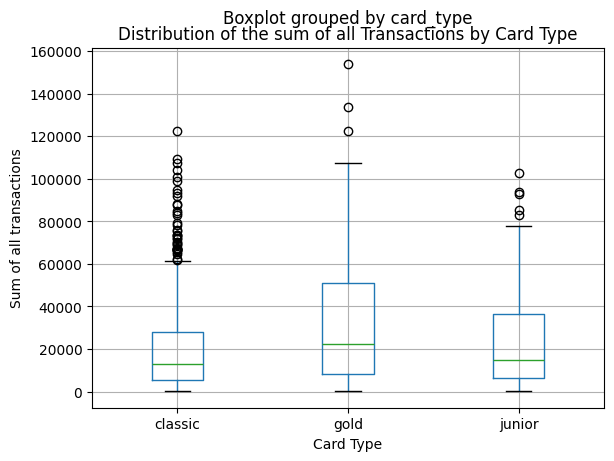

In [1034]:
# I wanna be able to display the spread data in a graph for ease of comparison later

# Display the spread as a boxplot
boxplot = df.boxplot(column='sum_all_trans', by='card_type')
pyp.title('Distribution of the sum of all Transactions by Card Type')
pyp.xlabel('Card Type')
pyp.ylabel('Sum of all transactions')
pyp.show()

In [1035]:
# Need to drop outliers
# Split the data into 3 df based on card_type
gold_df = df[df['card_type'] == 'gold']
classic_df = df[df['card_type'] == 'classic']
junior_df = df[df['card_type'] == 'junior']

# Function to get remove outliers in the data for a given dataframe
# Returns a new dataframe without outliers
def remove_outliers(data):
    Q1 = data['sum_all_trans'].quantile(0.25)
    Q3 = data['sum_all_trans'].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    return data[(data['sum_all_trans'] >= lower_limit) & (data['sum_all_trans'] <= upper_limit)]

# Remove outliers
gold_df = remove_outliers(gold_df)
classic_df = remove_outliers(classic_df)
junior_df = remove_outliers(junior_df)

# Concatinate them all and replace df with the new dataframe
df_cleaned = pd.concat([gold_df, classic_df, junior_df], ignore_index=True)
df = df_cleaned
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   card_type      761 non-null    object 
 1   sum_all_trans  761 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


I'm going to do an Anova test to determine if there is a significant difference in spending across the 3 card types, as Anova testing is used to test the differences in means of several groups.

Hypotheses:
* H0 : Card type does not affect spending; μJ(Junior) = μC(Classic) = μG(Gold)

* H1: There is at least one statistically significant difference in spending due to card type; μJ ≠ μC ≠  μG

In [1036]:
# Creating a sample
# Need to break the datframe into each card_type again for cleaned data
gold_df = df[df['card_type'] == 'gold']
classic_df = df[df['card_type'] == 'classic']
junior_df = df[df['card_type'] == 'junior']

#We want the same number of data points for each type so check number of rows
print(junior_df.shape[0])
print(classic_df.shape[0])
print(gold_df.shape[0])


126
554
81


In [1037]:
# Sample n members randomly with replacement for k times
# Sample mean variables
n = 20
k = 10

def get_sample_means(df, n, k):
    sample_means_list = []
    for x in range(k):
        mean_samples = []
        sample = df.sample(n=n)
        sample_mean = sample['sum_all_trans'].mean()
        mean_samples.append(sample_mean)
        sample_means_list.extend(mean_samples) 
    return sample_means_list

# Perform random sampling for each card type using dataframes created before
sampled_junior_list = get_sample_means(junior_df, n, k)
sampled_classic_list = get_sample_means(classic_df, n, k)
sampled_gold_list = get_sample_means(gold_df, n, k)

In [1038]:
# Calculate standard error for each type
se_junior = np.std(sampled_junior_list, ddof=1) / np.sqrt(n)
se_classic = np.std(sampled_classic_list, ddof=1) / np.sqrt(n)
se_gold = np.std(sampled_gold_list, ddof=1) / np.sqrt(n)

print("Standard Error for Junior:", se_junior)
print("Standard Error for Classic:", se_classic)
print("Standard Error for Gold:",se_gold)


# Calculate 
cv_junior = (se_junior / np.mean(sampled_junior_list)) * 100
cv_classic = (se_classic / np.mean(sampled_classic_list)) * 100
cv_gold = (se_gold / np.mean(sampled_gold_list)) * 100

print("Coefficient of Variation for Junior:", cv_junior)
print("Coefficient of Variation for Classic:", cv_classic)
print("Coefficient of Variation for Gold:", cv_gold)


Standard Error for Junior: 823.7671680895168
Standard Error for Classic: 685.7382072546992
Standard Error for Gold: 1194.9106254351316
Coefficient of Variation for Junior: 3.7554063873151593
Coefficient of Variation for Classic: 4.288275950564063
Coefficient of Variation for Gold: 3.796199149953558


Relatively small SE and Coefficient of Variation so we can use these samples.

In [1039]:
f_statistic, p_value = stats.f_oneway(sampled_junior_list, sampled_classic_list, sampled_gold_list)

# Print the results
print("F-statistic:", f_statistic)
print("P-value:", p_value)

# Decide whether to reject the null hypothesis based on the p-value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in spending across card types.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in spending across card types.")

F-statistic: 35.52770087274385
P-value: 2.7450183402881695e-08
Reject the null hypothesis. There is a significant difference in spending across card types.


In [1040]:
bonf = 0.05 / 3  # Bonferroni-corrected significance level for three pairwise tests

# Conduct pairwise t-tests
tG_junior_classic = stats.ttest_ind(sampled_junior_list, sampled_classic_list)
tG_junior_gold = stats.ttest_ind(sampled_junior_list, sampled_gold_list)
tG_classic_gold = stats.ttest_ind(sampled_classic_list, sampled_gold_list)

print("Adjusted p crit : ", (bonf / 2))

# Print results for each pairwise comparison
print("t-test between Junior and Classic:")
print("p-value:", tG_junior_classic.pvalue)
print()

print("t-test between Junior and Gold:")
print("p-value:", tG_junior_gold.pvalue)
print()

print("t-test between Classic and Gold:")
print("p-value:", tG_classic_gold.pvalue)


Adjusted p crit :  0.008333333333333333
t-test between Junior and Classic:
p-value: 0.0009999149878932043

t-test between Junior and Gold:
p-value: 0.00019980910689610778

t-test between Classic and Gold:
p-value: 2.689006086477365e-07


My test:

Adjusted p crit :  0.008333333333333333

t-test between Junior and Classic:
p-value: 0.09065609212327212

t-test between Junior and Gold:
p-value: 0.004386998130133368

t-test between Classic and Gold:
p-value: 5.51592373281387e-05

With this we can conclude there is a statistically significant difference between spending on a Junior or Classic card when compared to a gold card.

Plot the means of each card type on a bar chart

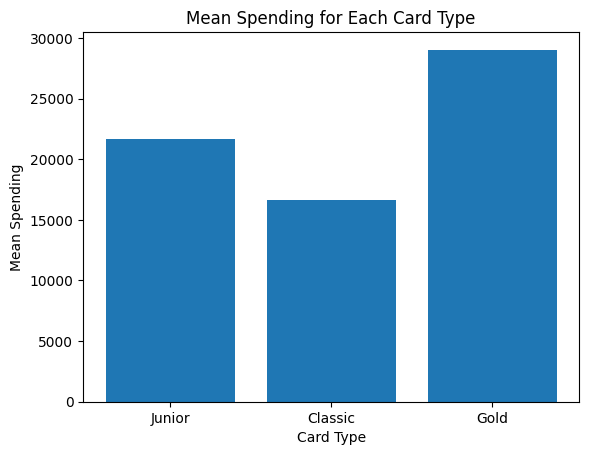

In [1041]:
mean_gold = gold_df['sum_all_trans'].mean()
mean_classic = classic_df['sum_all_trans'].mean()
mean_junior = junior_df['sum_all_trans'].mean()

# Create a bar plot
pyp.bar(['Junior', 'Classic', 'Gold'], [mean_junior, mean_classic, mean_gold])
pyp.title('Mean Spending for Each Card Type')
pyp.xlabel('Card Type')
pyp.ylabel('Mean Spending')
pyp.show()

Shows there is greater spending on gold card, so the initial hypothesis was correct people with better credit cards spend more money with them

# Model 4

This model will attempt to attempt to group customers based on their average spending and their birth_number using K-Means clustering.

In [1042]:
# Contruct our dataframe from the database

# Open a connection
connection = create_connection(fileDB)

# Load our queries to get the dataframe we need

# Transaction table
loadQuery  = "SELECT account_id, trans_amount FROM 'Transaction'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfTrans = dfDB

# Account table
loadQuery  = "SELECT account_id, disp_id FROM 'Account'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfAccount = dfDB 

# Disponent table
loadQuery  = "SELECT client_id, disp_id, account_id FROM 'Disponent'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfDisp = dfDB

# Client table
loadQuery  = "SELECT birth_number, client_id FROM 'Client'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfClient = dfDB

connection.close()

# Build our dataframe with merges
df = pd.merge(dfTrans, dfAccount, on='account_id', how='left')
df = pd.merge(df, dfDisp, on=['account_id', 'disp_id'], how='left')
df = pd.merge(df, dfClient, on='client_id', how='left')

# Get an average trans_amount per account 
avg_trans_amount_per_account = df.groupby('account_id')['trans_amount'].mean().reset_index()
avg_trans_amount_per_account.rename(columns={'trans_amount': 'avg_trans_amount_per_account'}, inplace=True)
df = pd.merge(df, avg_trans_amount_per_account, on='account_id', how='left')

# Get an average trans_amount per client
avg_trans_amount_per_client = df.groupby('client_id')['avg_trans_amount_per_account'].mean().reset_index()
avg_trans_amount_per_client.rename(columns={'avg_trans_amount_per_account': 'avg_trans_amount'}, inplace=True)

df = pd.merge(df, avg_trans_amount_per_client, on='client_id', how='left')

# Clean the dataframe
df = df[['birth_number', 'avg_trans_amount']]

# Check for null values
df.info()

Connection to SQLite DB successful


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 2 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   birth_number      1056320 non-null  int64  
 1   avg_trans_amount  1056320 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 16.1 MB


In [1043]:
# Get sample
df_sample = df.sample(n=100)

# Convert the sampled DataFrame to a NumPy array so we can input to Kmeans
sample_array = df_sample.values

In [1044]:
# Generate K-Means model
km = KMeans(n_clusters=3)

# Generate predictions
y_pred = km.fit_predict(sample_array)
random_data = df_sample.sample(n=1).values

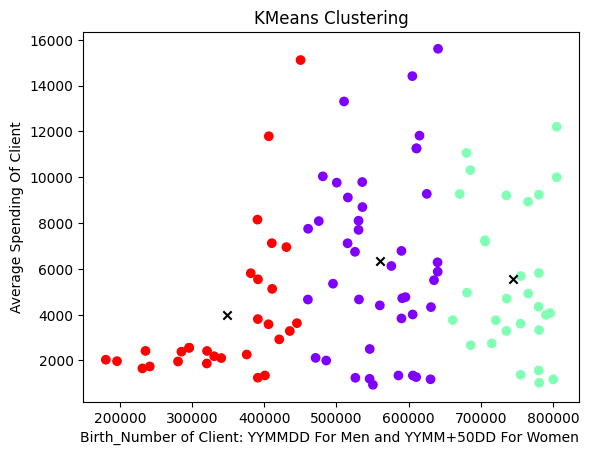

In [1045]:
# Create our scatter plot from our predictions and our sample
plt.scatter(sample_array[:,0], sample_array[:,1], c=km.labels_, cmap='rainbow')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='black', marker='x')

plt.xlabel('Birth_Number of Client: YYMMDD For Men and YYMM+50DD For Women ')  
plt.ylabel('Average Spending Of Client') 

# Add title
plt.title('KMeans Clustering')

plt.show()

From this graph we can get an idea of different generations spending habits, so the grouping was a success.

# Model 5
Hypothesis test: Men spend more than Women


In [1083]:
# Get a dataframe

# Open a connection
connection = create_connection(fileDB)

# Account table
loadQuery  = "SELECT account_id, disp_id FROM 'Account'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfAccount = dfDB 

# Transaction table
loadQuery  = "SELECT operation, trans_amount, account_id From 'Transaction'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfTrans = dfDB

# Client women table
loadQuery = "SELECT client_id, birth_Number FROM Client WHERE CAST(birth_Number AS TEXT) LIKE '__6%' OR CAST(birth_Number AS TEXT) LIKE '__5%';"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfClientWomen = dfDB

# Client men table
loadQuery  = "SELECT client_id, birth_Number from Client WHERE NOT CAST(birth_Number AS TEXT) LIKE '__6%' OR CAST(birth_Number AS TEXT) LIKE '__5%';"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfClientMen = dfDB

# Disponent table
loadQuery  = "SELECT client_id, disp_id, account_id FROM 'Disponent'"
dfDB = pd.read_sql_query(sql=loadQuery, con=connection)
dfDisp = dfDB


# Get an sum spending for each account
sum_trans_df = dfTrans.groupby('account_id')['trans_amount'].sum().reset_index()
sum_trans_df.rename(columns={'trans_amount': 'sum_trans_amount'}, inplace=True)

# Combine using left joins
df = pd.merge(dfAccount, dfTrans, on='account_id', how='left')
df = pd.merge(df, sum_trans_df, on='account_id', how='left')
df = pd.merge(df, dfDisp, on=['account_id', 'disp_id'], how='left')

# Filter for necessary columns
df = df[['sum_trans_amount', 'client_id']]

df_men = pd.merge(dfClientMen, df, on='client_id', how='left')
df_women = pd.merge(dfClientWomen, df, on='client_id', how='left')

df_men.dropna(inplace=True)
df_women.dropna(inplace=True)

mean_total_trans_women = df_women['sum_trans_amount'].mean()
men_avg_trans_amount = df_men['sum_trans_amount'].tolist()

Connection to SQLite DB successful


Now we have our data we can start our hypothesis test
* H0 : μ  = average_total_trans_women
* H1:  μ > average_total_trans_women

In [1086]:
# Get dofF
dofF = len(men_avg_trans_amount) - 1

# Perform t test
t = stats.ttest_1samp(men_avg_trans_amount, popmean=mean_total_trans_women)
print("T value:", t.statistic)

# Get critical value
t_crit = stats.t.ppf(0.05, df=dofF)
print("T critical:", t_crit)

#Using the p value and alpha significance level
print("p=%.3f > %.3f=α -> H0 is not rejected (not lower than α) " %(t.pvalue, alpha))

T value: 10.084378096494051
T critical: -1.644855271054018
p=0.000 > 0.050=α -> H0 is not rejected (not lower than α) 


We don't have enough data to show that men have statistically significant larger avg trans_amount than women. 

----
----

## Task 4: Experimental Results and Analysis (25 Marks)

Given the **five** modelling solutions implemented above, analyse, discuss and present your findings to the key stakeholders of the bank.

Your answer should clearly cover the following:
* Present your findings in a clear and concise manner;
* Discuss your results in the context of the selected solution;
* Discuss how these results can help the bank in performing customer risk assessment and establishing customer retention strategies;
* Present the limitations (if any) of your solutions in a clear and concise manner.

**World Limit**: 500 words. This limit applies only to the explanations. There is no limit on any associated code or figures.

**Write your answer here (text cell(s) to be used, as appropriate)**

# Model 1
The model I created was unable to accurately predict loan status based on the crime, unemployment and number of entrepreneurs per 1000. This suggests that there is not a strong correlation between my independent variables and loan_status. This means the bank cannot reasonably perform risk assessment on a loan for a client based on the client’s city of residence.


# Model 2
This model was more successful in predicting loan_status from it;s independent variables, suggesting a stronger correlation between loan_status and other fields in the Loan table. It is reasonable to use the model to perform some kind of initial risk assessment on a client applying for a loan, based on loans the bank has agreed to in the past. The model does not have the greatest accuracy however and it would be sensible to perform secondary checks on a client before approving a loan.

# Model 3
Using this model I was able to find that clients with gold credit cards tend to spend more money with them. This can be used to predict which credit card is best for a client based on their transaction history. A client can benefit from this by either having a better card, or if they aren’t using their current card as much as they could be, they could be recommended to get a less expensive card. This would help clients feel like the bank is doing their best to look after their clients and help boost customer retention.
(I am assuming that a gold card costs more to keep than a classic or junior card)


# Model 4
This model can be used to show that client’s spending habits split based on their generation (rough age groups). The bank can use this to predict what a client might need based on their age group, which would increase customer satisfaction. It also can be used to catch any strange payments that could be fraudulent: older generations tend to spend less and fall for scams more often. Any exceptional transaction would stand out as the vast majority of payments are at the lower end of the spectrum in the older generations. The model is limited in younger generations as the spread of the data is much less predictable.

# Model 5
The final model is a hypothesis test whether men have larger average transaction amounts than women. However our hypothesis was rejected. This shows that the bank cannot advertise to one group specifically, or discriminate against either group when it comes to eligibility for loans.

In [1046]:
### Write your answer here (code cell(s) to be used, as appropriate)


----
----

## Task 5: Conclusion (10 Marks)

Given the insights derived from Tasks 1-4, provide a conclusion that clearly covers the following:
* A summary of the main points;
* A discussion of the significance of your results;
* Any recommendation(s) resulting from your analysis;
* Any overall ethical considerations arising from the data analysis of this business domain.

**World Limit**: 300 words.

**Write your answer here (text cell(s) to be used, as appropriate)**
IN summary, the bank cannot use gender or city of residence to make decisions about a clients loan eligibility or any advertising towards that client. They can use any current loans, the transaction history or age of a client to help them make decisions though. From this I would recommend the bank placing checks on any outstanding loans from a client before issuing a new one. They should advertise the gold card more to bigger spenders than any one else. The bank should be careful when using age to determine things about a client however as this could lead to discrimantion.

In [1047]:
### Write your answer here (code cell(s) to be used, as appropriate)


----
----

## Overall Academic Quality (10 Marks)
10 marks are allocated for the clarity and cohesiveness of your answers (both text and code) across all tasks with appropriate, relevant and effective analysis and presentation of the results.

## Deliverables

You should submit the following to the submission point on the teaching portal:

1. the SQLite database produced in Task 2;
2. the completed Jupyter notebook (both .ipynb and HTML files) that also includes the SQL statements (Task 2), the research design and its implementation (Task 3), and the analysis and presentation of your results (Task 4);
3. any figures or diagrams that are included in your answers in the Jupyter notebook.

For each task where text is required, we have provided guidelines above on the suggested word counts. Exceeding the word count will result in any work beyond the word count being disregarded when assessing.